# ZINC Generation Demo

This notebook is the maintained ZINC-focused Conditional Node Field demo.

It downloads a large ZINC molecular table once, caches the converted NetworkX molecular graphs on disk, and lets you resume later without rebuilding the dataset or retraining the generator.

In [1]:
# Enable inline plotting and autoreload for ZINC exploration.
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

_repo_candidates = [Path.cwd(), Path.cwd().parent]
for _root in _repo_candidates:
    if (_root / 'conditional_node_field_graph_generator').exists():
        REPO_ROOT = _root.resolve()
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise ModuleNotFoundError("Could not locate 'conditional_node_field_graph_generator'.")

_nsppk_candidates = []
if os.environ.get("NSPPK_ROOT"):
    _nsppk_candidates.append(Path(os.environ["NSPPK_ROOT"]).expanduser())
_nsppk_candidates.extend([
    REPO_ROOT / 'NSPPK',
    REPO_ROOT.parent / 'NSPPK',
    Path.cwd() / 'NSPPK',
    Path.cwd().parent / 'NSPPK',
])
for _nsppk_root in _nsppk_candidates:
    _candidate = _nsppk_root.resolve()
    if _candidate.exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise ModuleNotFoundError("Could not locate NSPPK. Set NSPPK_ROOT or clone NSPPK next to this repo.")

ARTIFACT_ROOT = REPO_ROOT / '.artifacts'
NOTEBOOK_DATA_ROOT = REPO_ROOT / 'notebooks' / 'datasets'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'checkpoints' / 'node_field'

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

PyTorch version: 2.2.2
CUDA available: False


## Helpers

The helper cell below keeps the molecule display and sampling utilities local to this notebook, including a simple endpoint sampler for interpolation experiments.

In [2]:
# Import the molecule drawing helper and define notebook-local display utilities.
from coco_grape.visualizer.mol_display import draw_molecules


def show_molecules(graphs, n=12, title=None):
    graphs = list(graphs)[:n]
    if title:
        print(title)
    if not graphs:
        print("No graphs to display.")
        return
    draw_molecules(graphs)


def label_counter(graphs, kind="node"):
    counts = {}
    if kind == "node":
        for graph in graphs:
            for _, attrs in graph.nodes(data=True):
                label = attrs.get("label")
                counts[label] = counts.get(label, 0) + 1
    elif kind == "edge":
        for graph in graphs:
            for _, _, attrs in graph.edges(data=True):
                label = attrs.get("label")
                counts[label] = counts.get(label, 0) + 1
    else:
        raise ValueError("kind must be 'node' or 'edge'")
    return dict(sorted(counts.items(), key=lambda item: str(item[0])))


def summarize_graphs(graphs, prefix="dataset"):
    node_counts = np.array([graph.number_of_nodes() for graph in graphs], dtype=int)
    edge_counts = np.array([graph.number_of_edges() for graph in graphs], dtype=int)
    print(f"{prefix}: {len(graphs)} graphs")
    print(
        f"{prefix}: node count min/median/max = "
        f"{node_counts.min()}/{int(np.median(node_counts))}/{node_counts.max()}"
    )
    print(
        f"{prefix}: edge count min/median/max = "
        f"{edge_counts.min()}/{int(np.median(edge_counts))}/{edge_counts.max()}"
    )
    print(f"{prefix}: node labels = {label_counter(graphs, 'node')}")
    print(f"{prefix}: edge labels = {label_counter(graphs, 'edge')}")


def show_seed_and_samples(graph_generator, seed_graphs, n_seeds=6, title="Samples", apply_feasibility_filtering=None):
    # Show conditioning molecules first, then raw decoded samples, then feasibility-filtered samples.
    if apply_feasibility_filtering is None:
        apply_feasibility_filtering = APPLY_FEASIBILITY_FILTERING
    seed_graphs = list(seed_graphs)[:n_seeds]
    show_molecules(seed_graphs, n=n_seeds, title=f"{title}: conditioning molecules")

    raw_samples = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_seeds,
        apply_feasibility_filtering=False,
    )
    show_molecules(raw_samples, n=n_seeds, title=f"{title}: generated molecules without feasibility")

    if not apply_feasibility_filtering:
        return raw_samples

    feasible_samples = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_seeds,
        apply_feasibility_filtering=True,
    )
    show_molecules(feasible_samples, n=n_seeds, title=f"{title}: generated molecules with feasibility")
    return feasible_samples


def inspect_predicted_masks_and_edge_labels(graph_generator, graphs, n_graphs=6):
    # Inspect node-presence predictions and bond-label logits before full graph decoding.
    graph_conditioning = graph_generator.graph_encode(list(graphs)[:n_graphs])
    generated_nodes = graph_generator.conditional_node_generator_model.predict(graph_conditioning)

    observed_node_counts = graph_conditioning.node_counts[:n_graphs]
    predicted_node_counts = generated_nodes.node_presence_mask[:n_graphs].sum(axis=1)
    mask_frame = pd.DataFrame(
        {
            "conditioning_nodes": observed_node_counts,
            "predicted_nodes": predicted_node_counts,
            "conditioning_edges": graph_conditioning.edge_counts[:n_graphs],
        }
    )
    display(mask_frame)

    edge_label_matrices = generated_nodes.edge_label_matrices
    if edge_label_matrices is None:
        print("No edge-label matrices were predicted.")
    else:
        summaries = []
        for idx, matrix in enumerate(edge_label_matrices[:n_graphs]):
            labels, counts = np.unique(np.asarray(matrix, dtype=object), return_counts=True)
            summaries.append({"graph_idx": idx, **{str(label): int(count) for label, count in zip(labels, counts)}})
        display(pd.DataFrame(summaries).fillna(0).astype({"graph_idx": int}))

    decoded = graph_generator.graph_decoder.decode(
        generated_nodes,
        predicted_node_labels_list=generated_nodes.node_labels,
        predicted_edge_probability_matrices=generated_nodes.edge_probability_matrices,
        predicted_edge_label_matrices=generated_nodes.edge_label_matrices,
    )
    show_molecules(decoded, n=n_graphs, title="Decoded molecules from the inspected latent batch")
    return generated_nodes, decoded


def sample_random_endpoint_pair(graphs, rng=None):
    # Select two distinct molecules at random for interpolation experiments.
    if len(graphs) < 2:
        raise RuntimeError("Need at least two graphs for interpolation.")
    rng = np.random.default_rng() if rng is None else rng
    selected_indices = rng.choice(len(graphs), size=2, replace=False)
    return (
        selected_indices.tolist(),
        graphs[int(selected_indices[0])],
        graphs[int(selected_indices[1])],
    )

## Data

The dataset helpers below download a reusable ZINC CSV, cache the converted NetworkX molecular graphs, and reload the cached graph dataset on later runs. The default configuration targets 100,000 molecules.

Using cached ZINC CSV: /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/notebooks/datasets/zinc/zinc_250k.csv
Loaded cached ZINC graph corpus manifest: /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/notebooks/datasets/zinc/graph_corpus/manifest.pkl
Using cached ZINC CSV: /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/notebooks/datasets/zinc/zinc_250k.csv
Loaded cached ZINC graph corpus manifest: /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/notebooks/datasets/zinc/graph_corpus/manifest.pkl
Loaded ZINC graph slice (n=63134, min_node_count=15, max_node_count=20) from cached corpus: /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/notebooks/datasets/zinc/graph_corpus
ZINC CSV cache: /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/notebooks/datasets/zinc/zinc_250k.csv
ZINC graph cache root: /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/notebooks/datasets/zinc
Node-count filter: 15 <= n <= 20
Available node counts: [6, 7, 8,

,zinc_id,smiles,node_count,edge_count,logP,qed,SAS
0,None,O=C(CCCO)Nc1ccc(F)cc1F,15,15,1.6758,0.808810,1.728031
1,None,CCOc1ncnc(S(=O)(=O)CC)c1N,15,15,0.2511,0.764218,2.791969
2,None,CCCN(CC)c1cc[nH+]c(C(=O)[O-])c1,15,15,0.1005,0.707768,4.106739
3,None,CS(=O)(=O)[C@H]1O[C@H]1c1ccc(Cl)cc1Cl,15,16,2.4354,0.772831,3.421216
4,None,CC(=O)N[C@@H](C(=O)NC1COC1)C(C)C,15,15,-0.3379,0.696737,2.656179


,logP,qed,SAS
0,1.6758,0.808810,1.728031
1,0.2511,0.764218,2.791969
2,0.1005,0.707768,4.106739
3,2.4354,0.772831,3.421216
4,-0.3379,0.696737,2.656179


Example ZINC molecules


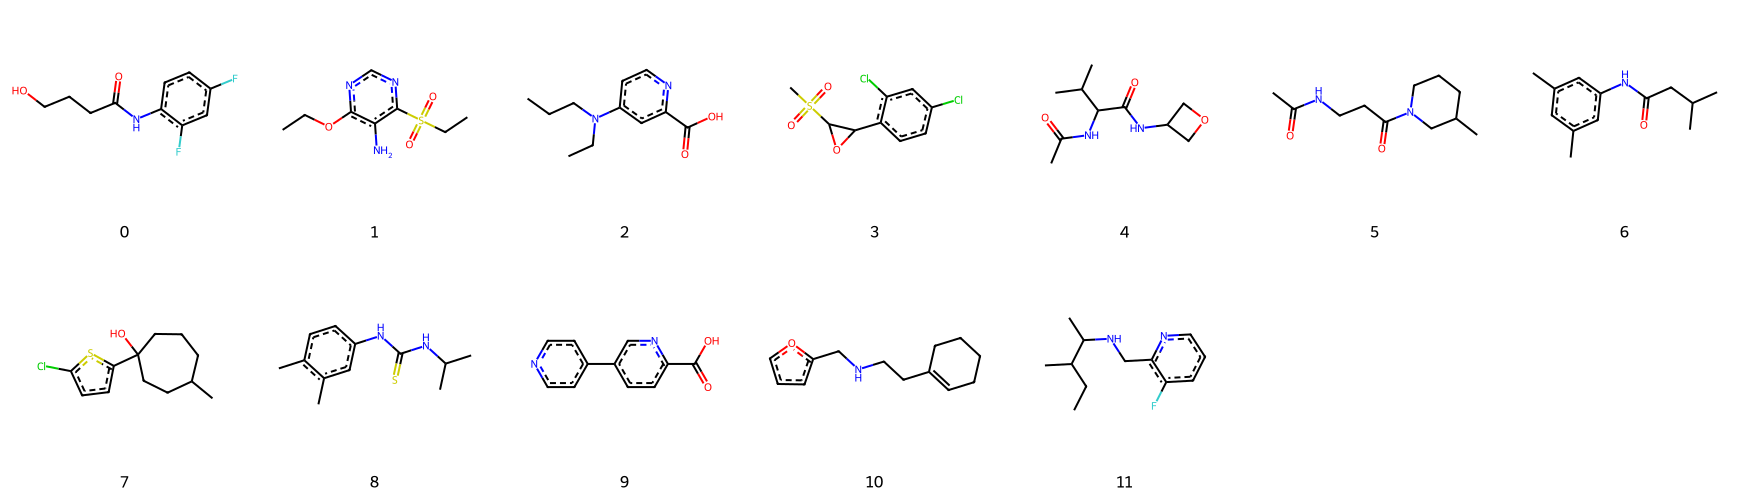

targets.shape=torch.Size([63134, 3])
train_graphs=62878 test_graphs=256
train_targets.shape=torch.Size([62878, 3]) test_targets.shape=torch.Size([256, 3])
DEBUG_MODE active: train_graphs=2000 test_graphs=32
DEBUG_MODE targets: train_targets.shape=torch.Size([2000, 3]) test_targets.shape=torch.Size([32, 3])
Debug subset training molecules


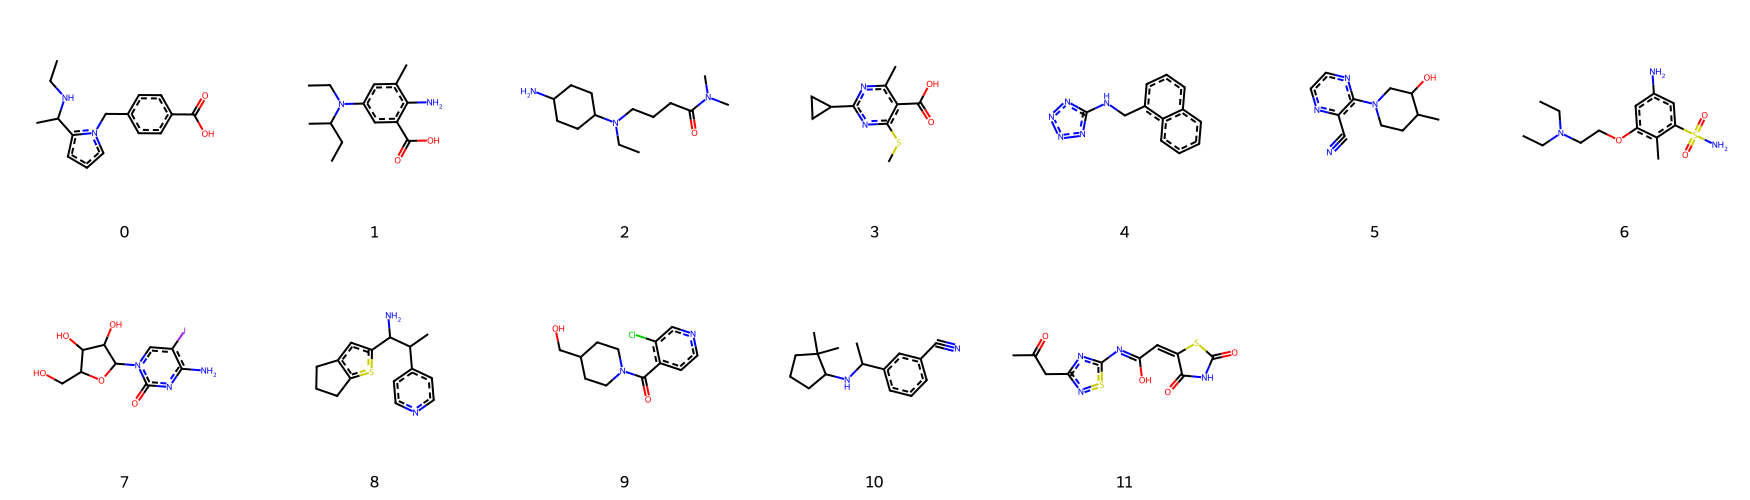

In [3]:
# Build the full cached ZINC graph corpus once, then load a node-count slice for training.
try:
    from notebooks.zinc_dataset_utils import (
        download_zinc_dataset,
        build_zinc_graph_corpus,
        load_zinc_graph_dataset,
        extract_zinc_targets,
        smiles_to_networkx_molecule,
    )
except ModuleNotFoundError:
    from zinc_dataset_utils import (
        download_zinc_dataset,
        build_zinc_graph_corpus,
        load_zinc_graph_dataset,
        extract_zinc_targets,
        smiles_to_networkx_molecule,
    )

from sklearn.model_selection import train_test_split

ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_MAX_MOLECULES = 250_000
MIN_NODE_COUNT = 15
MAX_NODE_COUNT = 20
TEST_SIZE = 256
RANDOM_STATE = 42
DEBUG_MODE = True
DEBUG_TRAIN_SUBSET = 2000
DEBUG_TEST_SUBSET = 32

csv_path = download_zinc_dataset(ZINC_DATA_ROOT)
corpus_manifest = build_zinc_graph_corpus(ZINC_DATA_ROOT, csv_path=csv_path)
graphs, zinc_metadata = load_zinc_graph_dataset(
    ZINC_DATA_ROOT,
    max_molecules=ZINC_MAX_MOLECULES,
    min_node_count=MIN_NODE_COUNT,
    max_node_count=MAX_NODE_COUNT,
)

print(f"ZINC CSV cache: {csv_path}")
print(f"ZINC graph cache root: {ZINC_DATA_ROOT}")
print(f"Node-count filter: {MIN_NODE_COUNT} <= n <= {MAX_NODE_COUNT}")
print(f"Available node counts: {corpus_manifest['node_counts'][:10]} ... {corpus_manifest['node_counts'][-10:]}")
target_columns = ['logP', 'qed', 'SAS']
targets = torch.tensor(
    extract_zinc_targets(zinc_metadata, target_columns=target_columns).to_numpy(dtype=np.float32),
    dtype=torch.float32,
)
summarize_graphs(graphs, prefix="zinc")
display(zinc_metadata.head())
display(pd.DataFrame(targets.numpy(), columns=target_columns).head())
show_molecules(graphs, n=12, title="Example ZINC molecules")

all_indices = np.arange(len(graphs))
effective_test_size = min(TEST_SIZE, max(1, len(all_indices) // 10))
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=effective_test_size,
    random_state=RANDOM_STATE,
)
train_graphs = [graphs[int(i)] for i in train_indices]
test_graphs = [graphs[int(i)] for i in test_indices]
train_metadata = zinc_metadata.iloc[train_indices].reset_index(drop=True)
test_metadata = zinc_metadata.iloc[test_indices].reset_index(drop=True)
train_targets = targets[torch.as_tensor(train_indices, dtype=torch.long)]
test_targets = targets[torch.as_tensor(test_indices, dtype=torch.long)]

print(f"targets.shape={targets.shape}")
print(f"train_graphs={len(train_graphs)} test_graphs={len(test_graphs)}")
print(f"train_targets.shape={train_targets.shape} test_targets.shape={test_targets.shape}")
if DEBUG_MODE:
    rng = np.random.default_rng(RANDOM_STATE)
    train_pick = rng.choice(len(train_graphs), size=min(DEBUG_TRAIN_SUBSET, len(train_graphs)), replace=False)
    test_pick = rng.choice(len(test_graphs), size=min(DEBUG_TEST_SUBSET, len(test_graphs)), replace=False)
    train_graphs = [train_graphs[int(i)] for i in train_pick]
    test_graphs = [test_graphs[int(i)] for i in test_pick]
    train_metadata = train_metadata.iloc[train_pick].reset_index(drop=True)
    test_metadata = test_metadata.iloc[test_pick].reset_index(drop=True)
    train_targets = train_targets[torch.as_tensor(train_pick, dtype=torch.long)]
    test_targets = test_targets[torch.as_tensor(test_pick, dtype=torch.long)]
    print(f"DEBUG_MODE active: train_graphs={len(train_graphs)} test_graphs={len(test_graphs)}")
    print(f"DEBUG_MODE targets: train_targets.shape={train_targets.shape} test_targets.shape={test_targets.shape}")
    show_molecules(train_graphs, n=12, title="Debug subset training molecules")


## Model

This configuration is explicitly ZINC-oriented. The generator is trained without external assay labels, so the notebook focuses on unconditional molecular structure modeling conditioned only on seed molecules.

Restart the kernel and rerun the notebook from the top after changing package code. Saved generators created before major API refactors may no longer reload.

In [4]:
# Configure and build the ZINC-oriented graph generator.
try:
    from notebooks.demo_pipeline_utils import build_graph_generator
except ModuleNotFoundError:
    from demo_pipeline_utils import build_graph_generator

try:
    from notebooks.notebook_utils import (
        save_graph_generator,
        load_graph_generator,
        list_saved_graph_generators,
    )
except ModuleNotFoundError:
    from notebook_utils import (
        save_graph_generator,
        load_graph_generator,
        list_saved_graph_generators,
    )

NBITS = 11
VERBOSE = 2
APPLY_FEASIBILITY_FILTERING = False
SAVED_GENERATOR_ROOT = ARTIFACT_ROOT / 'saved_generators'

graph_generator = build_graph_generator(
    nbits=NBITS,
    verbose=VERBOSE,

    # Model architecture
    latent_embedding_dimension=128,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    transformer_dropout=0.15,

    # Optimization and stopping
    learning_rate=2e-4,
    maximum_epochs=200,
    batch_size=16,
    total_steps=100,
    verbose_epoch_interval=10,
    enable_early_stopping=True,
    early_stopping_monitor='val_total',
    early_stopping_mode='min',
    early_stopping_patience=30,
    early_stopping_min_delta=10.0,
    restore_best_checkpoint=True,

    # Loss weights
    lambda_direct_edge_importance=2e3,
    lambda_auxiliary_edge_importance=1e3,
    lambda_degree_importance=1e3,
    lambda_degree_edge_consistency_importance=5e2,
    lambda_node_exist_importance=1e3,
    lambda_node_count_importance=5e2,
    lambda_node_label_importance=1e3,
    lambda_edge_label_importance=2e3,
    lambda_edge_count_importance=1e3,

    # Sampling
    degree_temperature=1.0,
    node_field_sigma=0.2,
    sampling_step_size=0.05,
    langevin_noise_scale=0.0,

    # Locality and feasibility
    locality_sample_fraction=0.5,
    locality_horizon=1,
    negative_sample_factor=1,
    locality_sampling_strategy='stratified_preserve',
    locality_target_positive_ratio=0.5,
    max_feasibility_attempts=5,
    feasibility_candidates_per_attempt=16,
    feasibility_failure_mode='return_partial',

    # Decoder
    decoder_enforce_connectivity=True,
    decoder_warm_start_mst=True,
    decoder_n_jobs=4,

    # Artifacts
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
)

## Fit

Fitting the graph generator on ZINC can be expensive. The save/resume section immediately after this cell is intended to let you inspect and sample later without retraining.

In [ ]:
%%time
# Fit the graph generator on the cached ZINC training molecules.
graph_generator.fit(train_graphs)

Fitting model on 2000 graphs
Fitting feasibility estimator on 2000 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 8 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 229836 pairs (50.00%) from 459672 total pairs (pos=153224, neg=306448, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=76612, neg=153224, positive_ratio=0.333.
Training conditional model on 2000 graphs with up to 20 nodes each.
Using direct-edge supervision with 229836 labelled pairs.
Lambda settings: degree=1000.000, node_exist=1000.000, node_count=500.000, node_label=1000.000, edge_label=2000.000, direct_ed

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Writing checkpoints to /Users/fabriziocosta/Resilio Sync/Sync/Projects/GraphGen/.artifacts/checkpoints/node_field/ConditionalNodeFieldGenerator_14a9e20e143c443280d162f98aecdaa0
Epoch 10/200 | ETA 2h 51m 42s:
  train total=  55611.0 | node_field   50866.4 [91.5%] |        deg     714.3 [1.3%] |      exist     110.0 [0.2%] | node_count      28.0 [<0.1%]
  val   total=  55042.4 | node_field   50589.0 [91.9%] |        deg     649.9 [1.2%] |      exist      97.4 [0.2%] | node_count      29.5 [<0.1%]
  train                 | node_label     143.1 [0.3%] | edge_label     495.7 [0.9%] |       edge    2768.3 [5.0%] | edge_count     334.2 [0.6%] | deg_edge_consistency     150.9 [0.3%] | dominant=node_field [91.5%]
  val                   | node_label      87.6 [0.2%] | edge_label     452.5 [0.8%] |       edge    2658.0 [4.8%] | edge_count     336.7 [0.6%] | deg_edge_consistency     141.8 [0.3%] | dominant=node_field [91.9%]
Epoch 20/200 | ETA 2h 32m 51s:
  train total=  54174.8 | node_field   50

## Save Or Resume The Fitted ZINC Generator

Saved generator filenames are intentionally short so you can copy them into a later session. This notebook uses the current Conditional Node Field artifact format only.

In [ ]:
# Save the fitted ZINC generator and print a short filename for later reuse.
MODEL_FILENAME = save_graph_generator(
    graph_generator,
    model_name='demo-zinc',
    model_dir=SAVED_GENERATOR_ROOT,
)
MODEL_FILENAME

In [ ]:
# Resume later with a copied filename from the save cell.
if False:
    list_saved_graph_generators(SAVED_GENERATOR_ROOT)
    MODEL_FILENAME = 'demo-zinc-20260307-0000-abcdef.pkl'
    graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)

## Inspect Masking And Bond Labels

Before decoding, inspect the latent predictions directly on a small batch of cached ZINC molecules.

In [ ]:
# Inspect predicted node masks and bond-label logits before full decoding.
inspected_nodes, inspected_graphs = inspect_predicted_masks_and_edge_labels(
    graph_generator,
    train_graphs[:6],
    n_graphs=6,
)

## Conditional Molecule Sampling

The sampling examples below condition on held-out ZINC molecules and draw the generated molecules with the chemistry-specific routines.

In [ ]:
# Generate raw conditional samples from held-out ZINC molecules.
raw_samples = graph_generator.sample_conditioned_on_random(
    test_graphs,
    n_samples=7,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)
show_molecules(raw_samples, n=8, title='Raw decoded ZINC molecules')

### Seed vs Sample Comparison

Show each seed molecule next to generated variants so feasibility filtering is easy to inspect.

In [ ]:
# Show the seed molecules next to unfiltered and feasibility-filtered samples.
show_seed_and_samples(
    graph_generator,
    test_graphs,
    n_seeds=6,
    title='Held-out ZINC conditioning set',
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)

## Random Endpoint Interpolation

Select two training molecules at random, interpolate between them, and display the endpoints plus generated intermediate molecules.

In [ ]:
# Interpolate between two random training molecules and decode the intermediate trajectory.
selected_indices, endpoint_graph_a, endpoint_graph_b = sample_random_endpoint_pair(train_graphs)
print('Endpoint indices:', selected_indices)
print('Endpoint A SMILES:', endpoint_graph_a.graph.get('smiles'))
print('Endpoint B SMILES:', endpoint_graph_b.graph.get('smiles'))

show_molecules([endpoint_graph_a, endpoint_graph_b], n=2, title='Selected endpoint molecules')

interpolation_result = graph_generator.interpolate(
    endpoint_graph_a,
    endpoint_graph_b,
    k=3,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)
display(interpolation_result['summary'])

missing_steps = interpolation_result['summary'].loc[
    ~interpolation_result['summary']['decoded'],
    'step',
].tolist()
if missing_steps:
    print('Interpolation steps rejected by feasibility filtering:', missing_steps)

show_molecules(
    [endpoint_graph_a, *interpolation_result['generated_graphs'], endpoint_graph_b],
    n=len(interpolation_result['generated_graphs']) + 2,
    title='Endpoints and generated interpolation molecules',
)

## Stochastic Training-Embedding Sampling

Sample new graph-level conditioning vectors by interpolating between pairs of cached training embeddings, then decode and display the resulting molecules.

In [ ]:
# Sample fresh graph-level conditions from cached training embeddings and decode them.
interpolated_samples = graph_generator.sample(
    n_samples=7 * 4,
    interpolate_between_n_samples=10,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)

print('Decoded stochastic interpolation samples:', len(interpolated_samples))
show_molecules(
    interpolated_samples,
    title='Samples from stochastic training-embedding interpolation',
)